In [24]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os, ast, sqlite3, re

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)

In [25]:
def cleanText(text):
    return re.sub(r'[^A-Za-z0-9]', '', text).strip().lower()

In [26]:
df = pd.read_csv('files/DataBase.csv')
df['installation_date'] = pd.to_datetime(df.installation_date, errors='coerce')
df['timestamp'] = pd.to_datetime(df.timestamp, errors='coerce')
df

,id,sensor_id,series_num,suntech_id,timestamp,updated_at,installed,telemetry,suntech,company,plate,installation_date
0,MIC8767790427121753,ETL4718937222929439,4,6.930862e+11,2026-01-06,2026-08-05 11:53:25.897924,True,entrack,6.930862e+11,leste,TFE6H05,2026-07-21
1,MIC7952031891471590,ETL7952031891471590,6,NaN,2026-03-18,2026-03-18 11:51:29.539832,True,mix,NaN,predileto,RJO6I53,2026-03-18
2,MIC1009016058992021,ETL8355798954801671,12,NaN,2024-07-05,2025-12-10 19:36:52.528153,True,mix,NaN,predileto,LUA5E58,2024-07-12
3,MIC3982343538817967,ETL3178405820036359,22,NaN,2024-09-02,2025-12-10 19:36:52.528153,True,mix,NaN,manchur,KYA9508,2024-09-23
4,MIC1700087363643403,ETL0644031280801291,25,NaN,2024-08-14,2025-12-10 19:36:52.528153,True,mix,NaN,logika,SRJ7J95,2024-07-15
...,...,...,...,...,...,...,...,...,...,...,...,...
133,MIC2824659041515651,ETL7016580521711403,325,1.700024e+09,2026-07-15,2026-07-15 18:49:21.741190,True,suntech,1.700024e+09,faje,LUO3I89,2026-07-25
134,MIC3746566632057495,ETL3850432974637703,327,6.930860e+11,2026-07-20,2026-07-27 16:38:04.600950,True,entrack,6.930860e+11,sighir,MALETA_SIGHIR,2026-06-01
135,MIC7161855067661432,ETL7161855067661432,329,1.700007e+09,2026-07-20,2026-07-20 17:17:00.633705,True,suntech,1.700007e+09,predileto,SRI3E32,2026-07-20
136,MIC2964578494695931,ETL6186117015801237,332,1.700024e+09,2026-07-23,2026-07-23 18:07:35.963291,True,suntech,1.700024e+09,ricker,TUH4A08,2026-08-04


# INFORMAÇÕES

In [27]:
telemetries = df.telemetry.unique()
telemetries

<StringArray>
['entrack', 'mix', 'suntech']
Length: 3, dtype: str

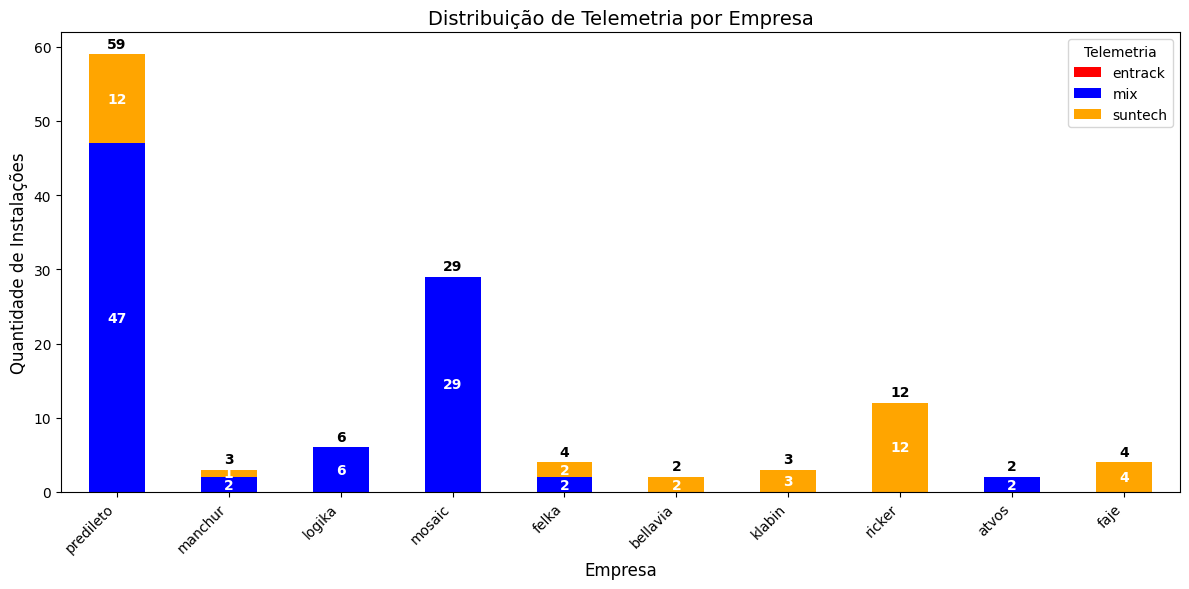

In [28]:
data = []

for company in df.company.unique():
    info = {'company': company}
    qtd  = 0

    for telemetry in df.telemetry.unique():
        target = df.loc[(df.installed) & (df.company == company) & (df.telemetry == telemetry)]
        info[telemetry] = len(target)
        qtd += len(target)
    
    if qtd > 1 and company != 'sighir':
        data.append(info)


df_resultado = pd.DataFrame(data)
df_plot = df_resultado.set_index('company')

fig, ax = plt.subplots(figsize=(12, 6))
df_plot.plot(kind='bar', stacked=True, ax=ax, color=['red', 'blue', 'orange'])

for container in ax.containers:
    labels = [int(v.get_height()) if v.get_height() > 0 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', color='white', fontweight='bold')

totais = df_plot.sum(axis=1)
for i, total in enumerate(totais):
    if total > 0: # Oculta o total para empresas zeradas (como zas e detector)
        ax.text(i, total + 0.5, int(total), ha='center', va='bottom', fontweight='bold', color='black')

plt.title('Distribuição de Telemetria por Empresa', fontsize=14)
plt.xlabel('Empresa', fontsize=12)
plt.ylabel('Quantidade de Instalações', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Telemetria')
plt.tight_layout()

In [29]:
df.loc[df.company == 'ricker'][['plate', 'installation_date', 'suntech']]

,plate,installation_date,suntech
66,JAO1G85,2025-12-04,1.700007e+09
72,SQZ7I20,2026-01-21,1.700010e+09
75,TTD7F73,2025-11-03,1.700010e+09
82,JBL6F29,2025-12-11,1.700010e+09
84,JBC1E74,2026-01-21,1.700010e+09
85,SQX8C74,2025-12-02,1.700017e+09
91,TTW7B29,2026-01-21,1.700025e+09
98,TUA3D42,2026-02-20,1.700007e+09
116,TUI6C37,2026-06-16,1.700024e+09
117,JAX7B99,2026-06-16,1.700024e+09


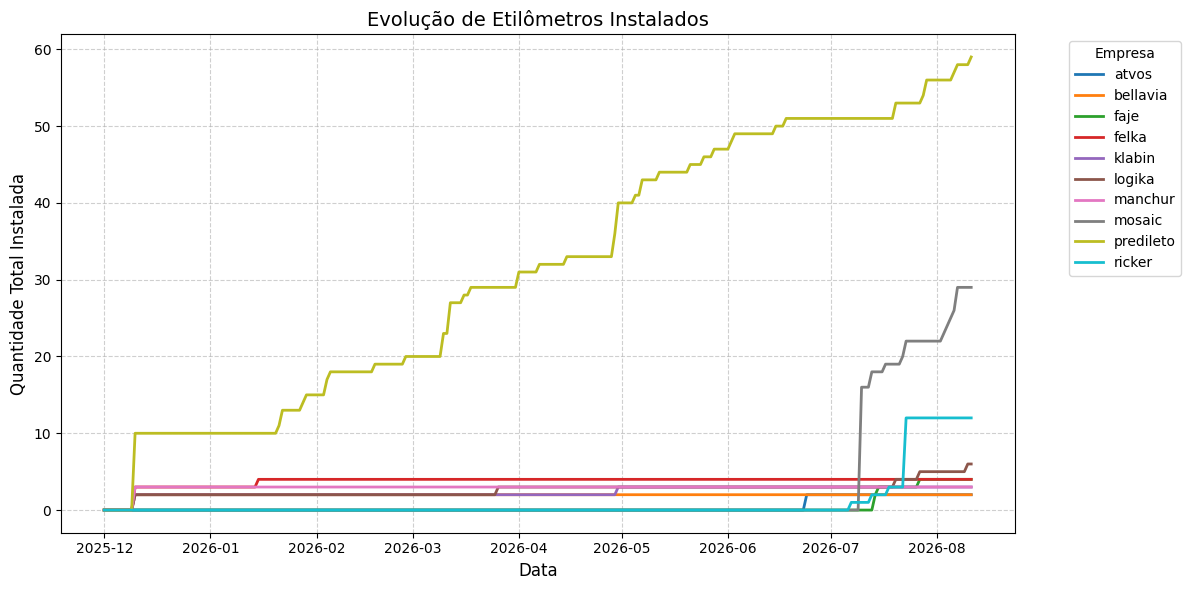

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

class InstallationTracker:
    def __init__(self, rawData):
        self.df = rawData.copy()

    def processData(self, dateColumn='updated_at', startDate='2025-12-01'):
        self.df[dateColumn] = pd.to_datetime(self.df[dateColumn])
        
        maskInstalled = self.df['installed'] == True
        maskCompany = self.df['company'] != 'sighir'
        maskDate = self.df[dateColumn] >= startDate
        
        filteredDf = self.df[maskInstalled & maskCompany & maskDate].copy()
        
        filteredDf['dateOnly'] = filteredDf[dateColumn].dt.date
        
        dailyCounts = filteredDf.groupby(['dateOnly', 'company']).size().unstack(fill_value=0)
        
        if not dailyCounts.empty:
            startTargetDate = pd.to_datetime(startDate).date()
            endTargetDate = dailyCounts.index.max()
            fullDateRange = pd.date_range(start=startTargetDate, end=endTargetDate).date
            
            dailyCounts = dailyCounts.reindex(fullDateRange, fill_value=0)
            
        cumulativeSum = dailyCounts.cumsum()
        
        if not cumulativeSum.empty:
            finalTotals = cumulativeSum.iloc[-1]
            validCompanies = finalTotals[finalTotals >= 2].index
            
            cumulativeSum = cumulativeSum[validCompanies]
            
        return cumulativeSum

    def plotCumulativeData(self, cumulativeData):
        if cumulativeData.empty or cumulativeData.columns.empty:
            return

        fig, ax = plt.subplots(figsize=(12, 6))
        
        cumulativeData.plot(kind='line', ax=ax, linewidth=2)
        
        plt.title('Evolução de Etilômetros Instalados', fontsize=14)
        plt.xlabel('Data', fontsize=12)
        plt.ylabel('Quantidade Total Instalada', fontsize=12)
        
        plt.legend(title='Empresa', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        
        plt.show()

tracker = InstallationTracker(df)
cumulativeInstallations = tracker.processData()
tracker.plotCumulativeData(cumulativeInstallations)

In [31]:
company = 'predileto'

target = df.loc[
    (df.company == company) &
    (df.installed == True) &
    (~df.plate.str.lower().str.contains('teste', na=False))
]

target.to_csv(f'output/{company}.csv')

data = {
    'instalados': len(target),
    'mix': (target.telemetry == 'mix').sum(),
    'suntech': (target.telemetry == 'suntech').sum(),
}

print(f'Empresa {company}')
display(pd.DataFrame([data]))
display(target.head())

Empresa predileto


,instalados,mix,suntech
0,59,47,12


,id,sensor_id,series_num,suntech_id,timestamp,updated_at,installed,telemetry,suntech,company,plate,installation_date
1,MIC7952031891471590,ETL7952031891471590,6,NaN,2026-03-18,2026-03-18 11:51:29.539832,True,mix,NaN,predileto,RJO6I53,2026-03-18
2,MIC1009016058992021,ETL8355798954801671,12,NaN,2024-07-05,2025-12-10 19:36:52.528153,True,mix,NaN,predileto,LUA5E58,2024-07-12
6,MIC3004645420106011,ETL2608402025435219,32,1.700007e+09,2024-09-06,2026-02-05 13:52:53.033824,True,suntech,1.700007e+09,predileto,RJT5E02,2026-02-06
7,MIC5282201573701056,ETL0683710290391369,39,NaN,2025-01-22,2026-08-06 11:34:47.926958,True,mix,NaN,predileto,PPQ9017,2026-05-06
8,MIC3823236370877649,ETL6578802337391315,40,NaN,2024-07-22,2026-05-07 18:43:47.443355,True,mix,NaN,predileto,SRV2A57,NaT


# SALVANNDO FORMATADOS

In [32]:
df = df.sort_values(by='company')
df.to_csv('output/relations.csv')
df.to_csv('output/general.csv', index=None)